# Loan Approval Dataset - Data Cleaning and EDA

#This notebook focuses on cleaning and analyzing the Loan Approval train dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

#Goal:
- Understand the dataset
- Handle missing values
- Clean categorical columns
- Detect outliers
- Perform exploratory data analysis
- Extract useful insights before machine learning

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("Loan_Train.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
df.shape

(614, 13)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [12]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [13]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [14]:
df.columns=df.columns.str.strip()
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [15]:
df = df.rename(columns={
    "Loan_ID": "loan_id",
    "Gender": "gender",
    "Married": "married",
    "Dependents": "dependents",
    "Education": "education",
    "Self_Employed": "self_employed",
    "ApplicantIncome": "applicant_income",
    "CoapplicantIncome": "coapplicant_income",
    "LoanAmount": "loan_amount",
    "Loan_Amount_Term": "loan_amount_term",
    "Credit_History": "credit_history",
    "Property_Area": "property_area",
    "Loan_Status": "loan_status"
})

df.head()

,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [16]:
df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

credit_history        8.143322
self_employed         5.211726
loan_amount           3.583062
dependents            2.442997
loan_amount_term      2.280130
gender                2.117264
married               0.488599
loan_id               0.000000
education             0.000000
applicant_income      0.000000
coapplicant_income    0.000000
property_area         0.000000
loan_status           0.000000
dtype: float64

In [17]:
df.duplicated().sum()

0

In [18]:
c_col=df.select_dtypes(include=["object","string","category"]).columns
c_col

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'property_area', 'loan_status'],
      dtype='str')

In [19]:
n_col=df.select_dtypes(include=["int64","float64"]).columns
n_col

Index(['applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history'],
      dtype='str')

In [20]:
for col in c_col:
    print(col)
    print(df[col].unique())
    print("-" * 40)

loan_id
<ArrowStringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str
----------------------------------------
gender
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
----------------------------------------
married
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
----------------------------------------
dependents
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
----------------------------------------
education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
----------------------------------------
self_employed
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
----------------------------------------
property_area
<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype

In [21]:
for c in c_col:
    df[c]=df[c].str.strip()

In [22]:
for col in c_col:
    print(col)
    print(df[col].unique())
    print("-" * 40)

loan_id
<ArrowStringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str
----------------------------------------
gender
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
----------------------------------------
married
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
----------------------------------------
dependents
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
----------------------------------------
education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
----------------------------------------
self_employed
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
----------------------------------------
property_area
<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype

In [23]:
for c in c_col:
    df[c]=df[c].fillna(df[c].mode()[0])


In [24]:
for col in n_col:
    df[col] = df[col].fillna(df[col].median())

In [25]:
df.isnull().sum()

loan_id               0
gender                0
married               0
dependents            0
education             0
self_employed         0
applicant_income      0
coapplicant_income    0
loan_amount           0
loan_amount_term      0
credit_history        0
property_area         0
loan_status           0
dtype: int64

In [26]:
df['credit_history']=df['credit_history'].astype('category')
df['loan_amount_term']=df['loan_amount_term'].astype('category')
df.dtypes

loan_id                    str
gender                     str
married                    str
dependents                 str
education                  str
self_employed              str
applicant_income         int64
coapplicant_income     float64
loan_amount            float64
loan_amount_term      category
credit_history        category
property_area              str
loan_status                str
dtype: object

In [27]:
df["loan_status"].value_counts()

loan_status
Y    422
N    192
Name: count, dtype: int64

In [28]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

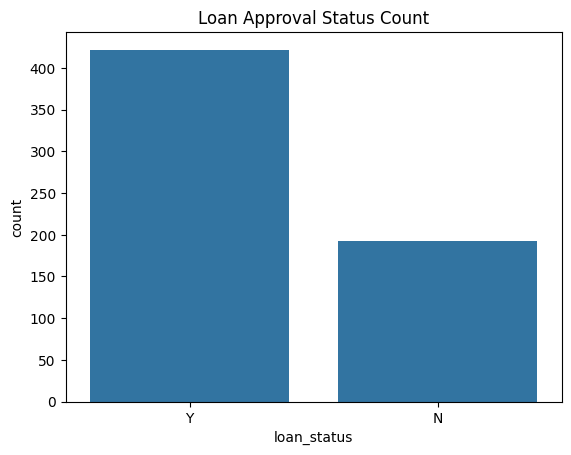

In [29]:
sns.countplot(data=df,x='loan_status')
plt.title("Loan Approval Status Count")
plt.show()

In [30]:
df[["applicant_income", "coapplicant_income", "loan_amount"]].describe()

,applicant_income,coapplicant_income,loan_amount
count,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443
std,6109.041673,2926.248369,84.107233
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.250000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,164.750000
max,81000.000000,41667.000000,700.000000


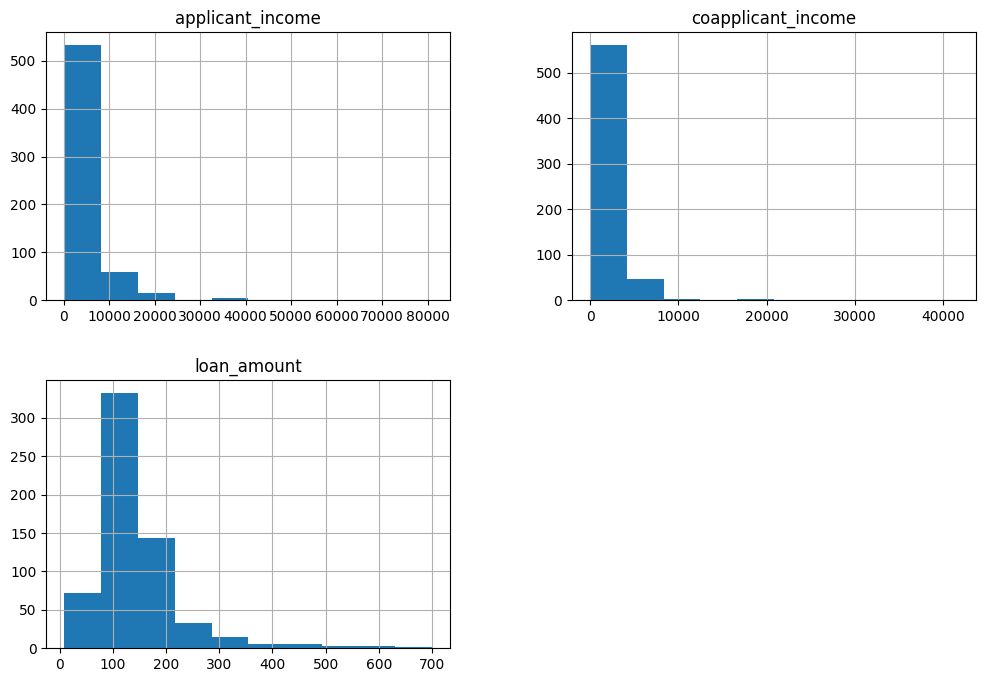

In [31]:
df[["applicant_income", "coapplicant_income", "loan_amount"]].hist(figsize=(12, 8))
plt.show()

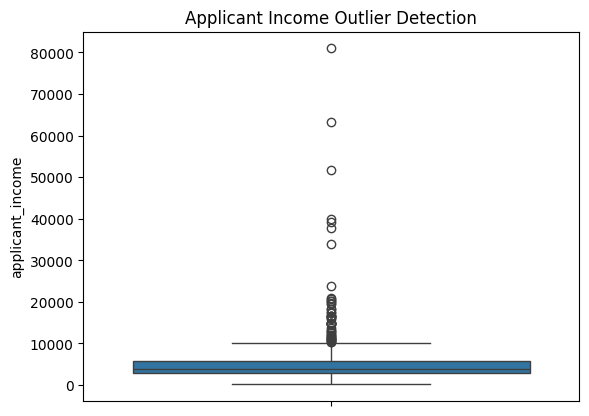

In [32]:
sns.boxplot(data=df, y="applicant_income")
plt.title("Applicant Income Outlier Detection")
plt.show()

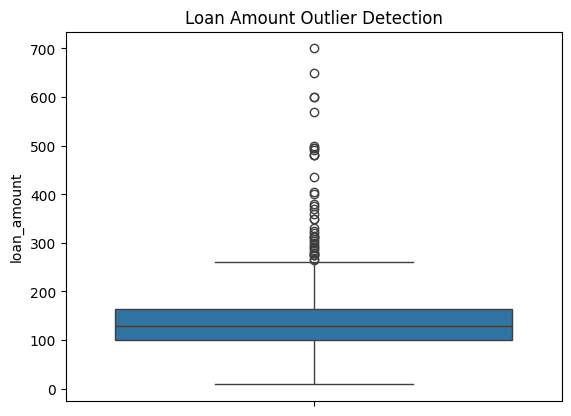

In [33]:
sns.boxplot(data=df, y="loan_amount")
plt.title("Loan Amount Outlier Detection")
plt.show()

In [34]:
df['total_income']=df['applicant_income']+df['coapplicant_income']
df[["applicant_income", "coapplicant_income", "total_income"]].head()

,applicant_income,coapplicant_income,total_income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [35]:
df.groupby('gender')["loan_status"].value_counts(normalize=True)*100

gender  loan_status
Female  Y              66.964286
        N              33.035714
Male    Y              69.123506
        N              30.876494
Name: proportion, dtype: float64

In [36]:
df.groupby("education")["loan_status"].value_counts(normalize=True) * 100

education     loan_status
Graduate      Y              70.833333
              N              29.166667
Not Graduate  Y              61.194030
              N              38.805970
Name: proportion, dtype: float64

In [37]:
df.groupby("credit_history")["loan_status"].value_counts(normalize=True) * 100

credit_history  loan_status
0.0             N              92.134831
                Y               7.865169
1.0             Y              79.047619
                N              20.952381
Name: proportion, dtype: float64

In [38]:
df.groupby("loan_status")[["applicant_income", "loan_amount", "total_income"]].mean()

,applicant_income,loan_amount,total_income
loan_status,,,
N,5446.078125,149.890625,7323.885417
Y,5384.068720,143.869668,6888.585118


In [39]:
df.groupby("loan_status")[["applicant_income", "loan_amount", "total_income"]].median()

,applicant_income,loan_amount,total_income
loan_status,,,
N,3833.5,128.0,5289.5
Y,3812.5,128.0,5439.0


Task was destroyed but it is pending!
task: <Task pending name='Task-625' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\vijib\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-626' coro=<Kernel.shell_main() running at C:\Users\vijib\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\vijib\AppData\Local\Programs\Python\Python312\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\vijib\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:132: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __enter__(self):
Task was destroyed but it is pending!
task: <Task pending name='Task-626' coro=<Kernel.shell_main() running at C:\Users\vijib\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]

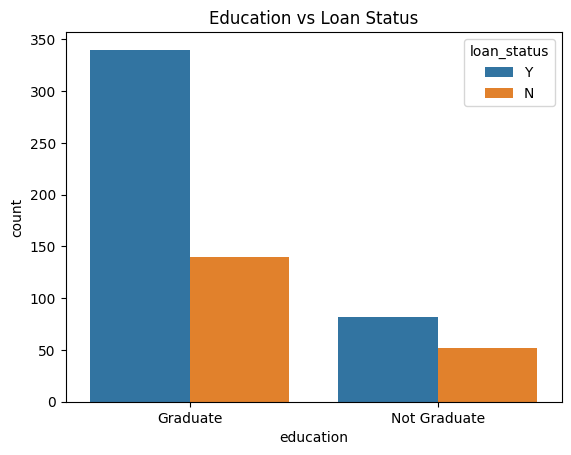

In [40]:
sns.countplot(data=df, x="education", hue="loan_status")
plt.title("Education vs Loan Status")
plt.show()

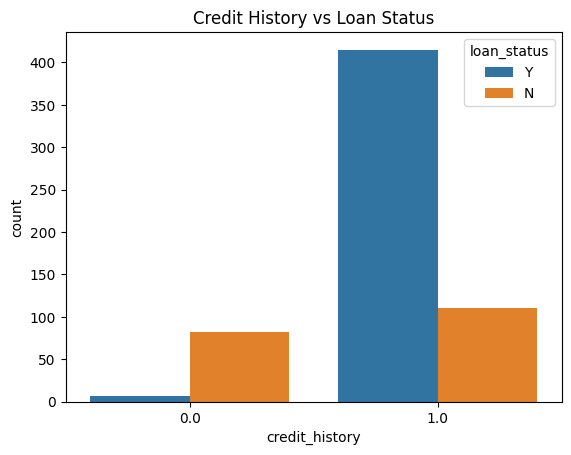

In [41]:
sns.countplot(data=df, x="credit_history", hue="loan_status")
plt.title("Credit History vs Loan Status")
plt.show()

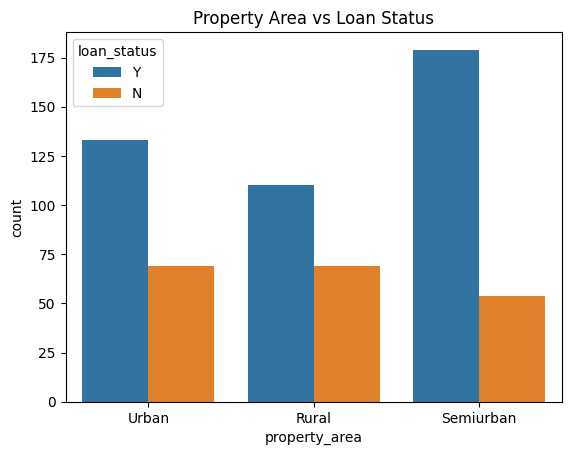

In [42]:
sns.countplot(data=df, x="property_area", hue="loan_status")
plt.title("Property Area vs Loan Status")
plt.show()

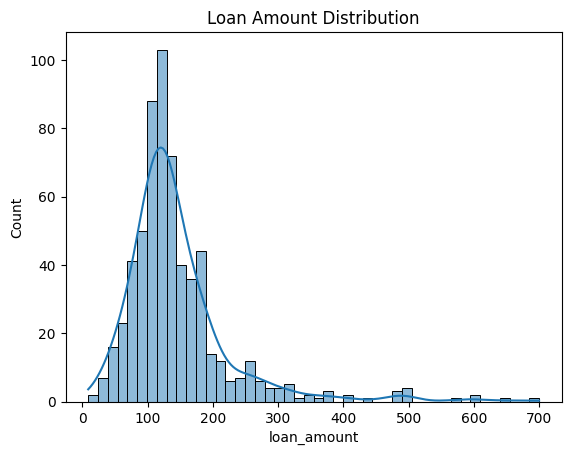

In [45]:
sns.histplot(df['loan_amount'],kde=True)
plt.title("Loan Amount Distribution")
plt.show()


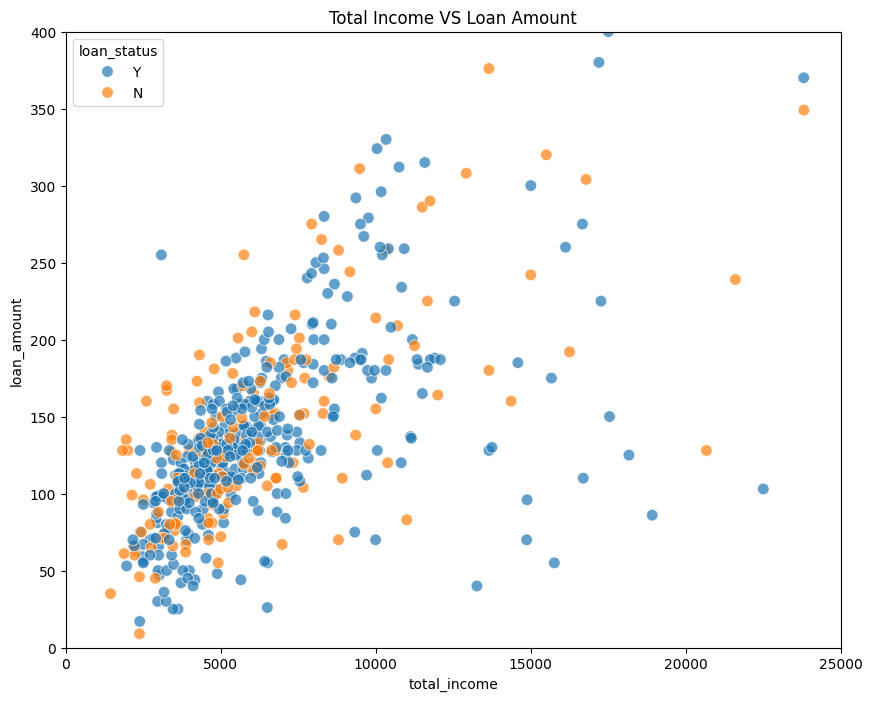

In [55]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="total_income",y="loan_amount",hue="loan_status",alpha=0.7,s=70)
plt.title("Total Income VS Loan Amount")
plt.xlim(0, 25000)
plt.ylim(0, 400)
plt.show()

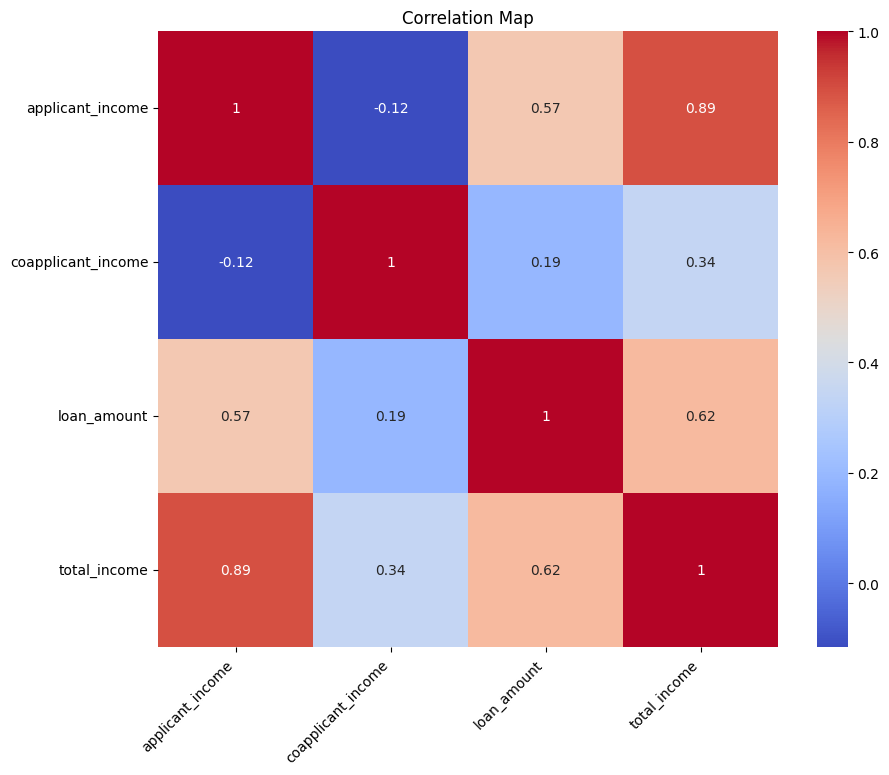

In [63]:
n_col=df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,8))
ax=sns.heatmap(n_col.corr(),annot=True,cmap="coolwarm", xticklabels=True,
    yticklabels=True)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
plt.title("Correlation Map")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [64]:
df.to_csv("cleaned_loan_train.csv", index=False)

## Final Insights

1. The dataset contains both categorical and numerical features related to loan applicants.
2. Missing values were handled using mode for categorical columns and median for numerical columns.
3. Duplicate rows were checked before analysis.
4. Applicant income, coapplicant income, and loan amount showed right-skewed distributions with possible outliers.
5. Credit history appears to be an important feature related to loan approval.
6. Total income was created by combining applicant income and coapplicant income.
7. Visualizations helped understand relationships between education, credit history, property area, income, loan amount, and loan status.
8. The cleaned dataset is now ready for machine learning model building.